In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import plotnine as p9
from sqlalchemy import create_engine, text

USERNAME = "ssubrahmanya"
DATAFOLDER = Path("../data/")
SEED = 42

engine = create_engine(
    f"mysql://{USERNAME}@/{USERNAME}?charset=utf8mb4",
    connect_args={
        "read_default_file": str(Path.home() / ".my.cnf")
    }
)

## Prepare data splits

In [4]:
message_table = "lead_en"
lead_en = pd.read_sql(f"SELECT * FROM {message_table}", engine)

train = lead_en \
    .sample(
        frac=0.6, 
        random_state=SEED
    )

train.to_sql(
    name=f"{message_table}_train", 
    con=engine, 
    if_exists="replace", 
    index=False
)  

sample = lead_en.drop(train.index)
valid = sample \
    .sample(
        frac=0.5, 
        random_state=SEED
    )

valid.to_sql(
        name=f"{message_table}_valid", 
        con=engine, 
        if_exists="replace", 
        index=False
    )

test = sample.drop(valid.index)
test.to_sql(
        name=f"{message_table}_test", 
        con=engine, 
        if_exists="replace", 
        index=False
    )

with engine.connect() as conn:
    conn.execute(text(f"ALTER TABLE {message_table}_train ADD PRIMARY KEY (message_id)"))
    conn.execute(text(f"ALTER TABLE {message_table}_valid ADD PRIMARY KEY (message_id)"))
    conn.execute(text(f"ALTER TABLE {message_table}_test ADD PRIMARY KEY (message_id)"))

print(f"train: {len(train)}, valid: {len(valid)}, test: {len(test)}")

train: 1175, valid: 392, test: 391


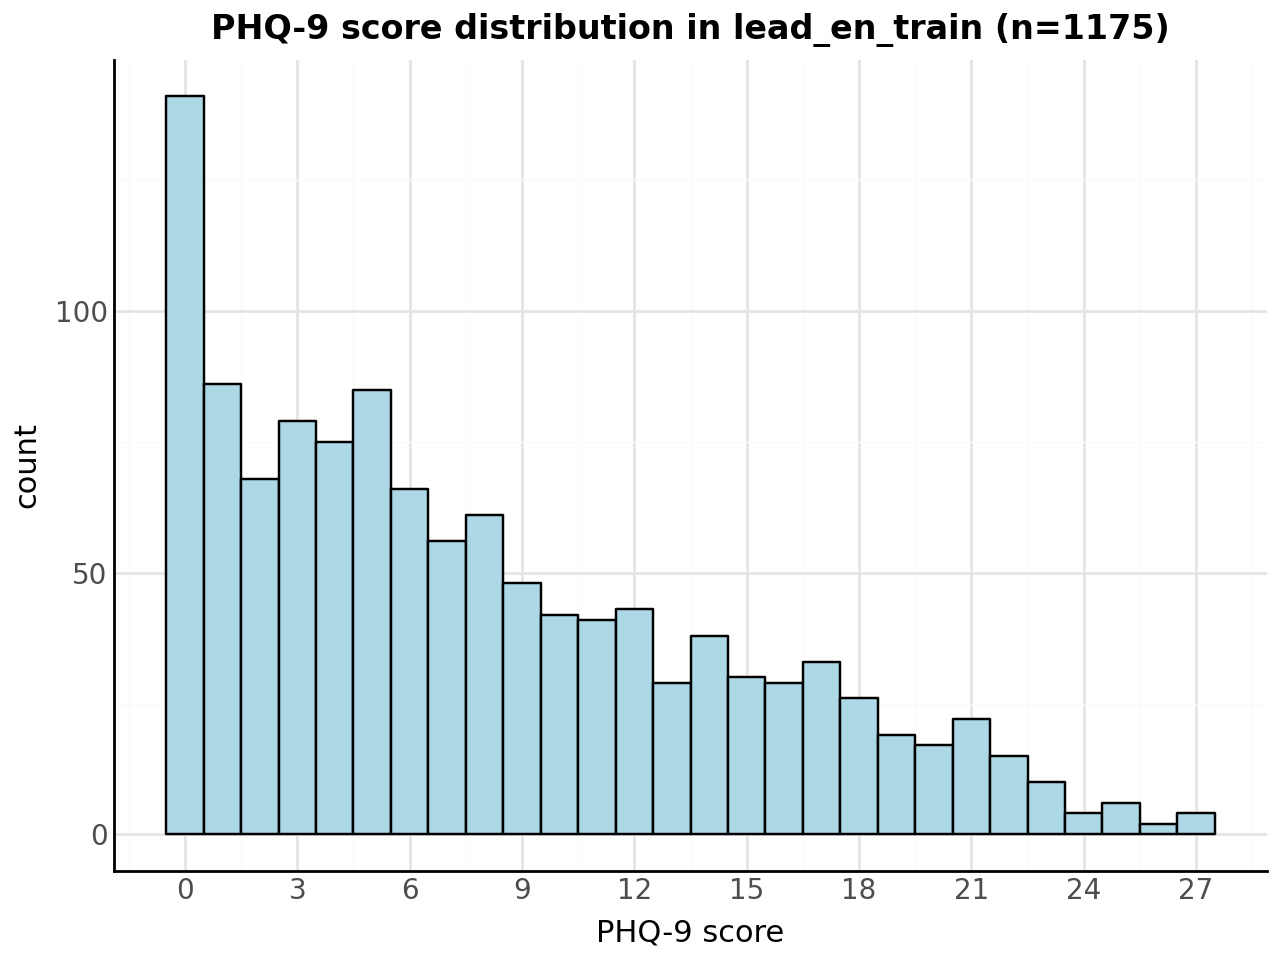

In [13]:
lead_en_train = pd.read_sql(f"SELECT message_id, message, phq9 FROM {message_table}_train", engine)

(
    p9.ggplot(lead_en_train, p9.aes(x="phq9")) + 
    p9.geom_histogram(binwidth=1, color="black", fill="lightblue") + 
    p9.scale_x_continuous(breaks=np.arange(0, 28, 3)) +
    p9.labs(
        x="PHQ-9 score",
        y="count",
        title=f"PHQ-9 score distribution in {message_table}_train (n={len(lead_en_train)})"
    ) +
    p9.theme_minimal() +
    p9.theme(
        axis_line=p9.element_line(color="black"),
        axis_text=p9.element_text(size=10),
        plot_title=p9.element_text(size=12, face="bold"),
    )
)

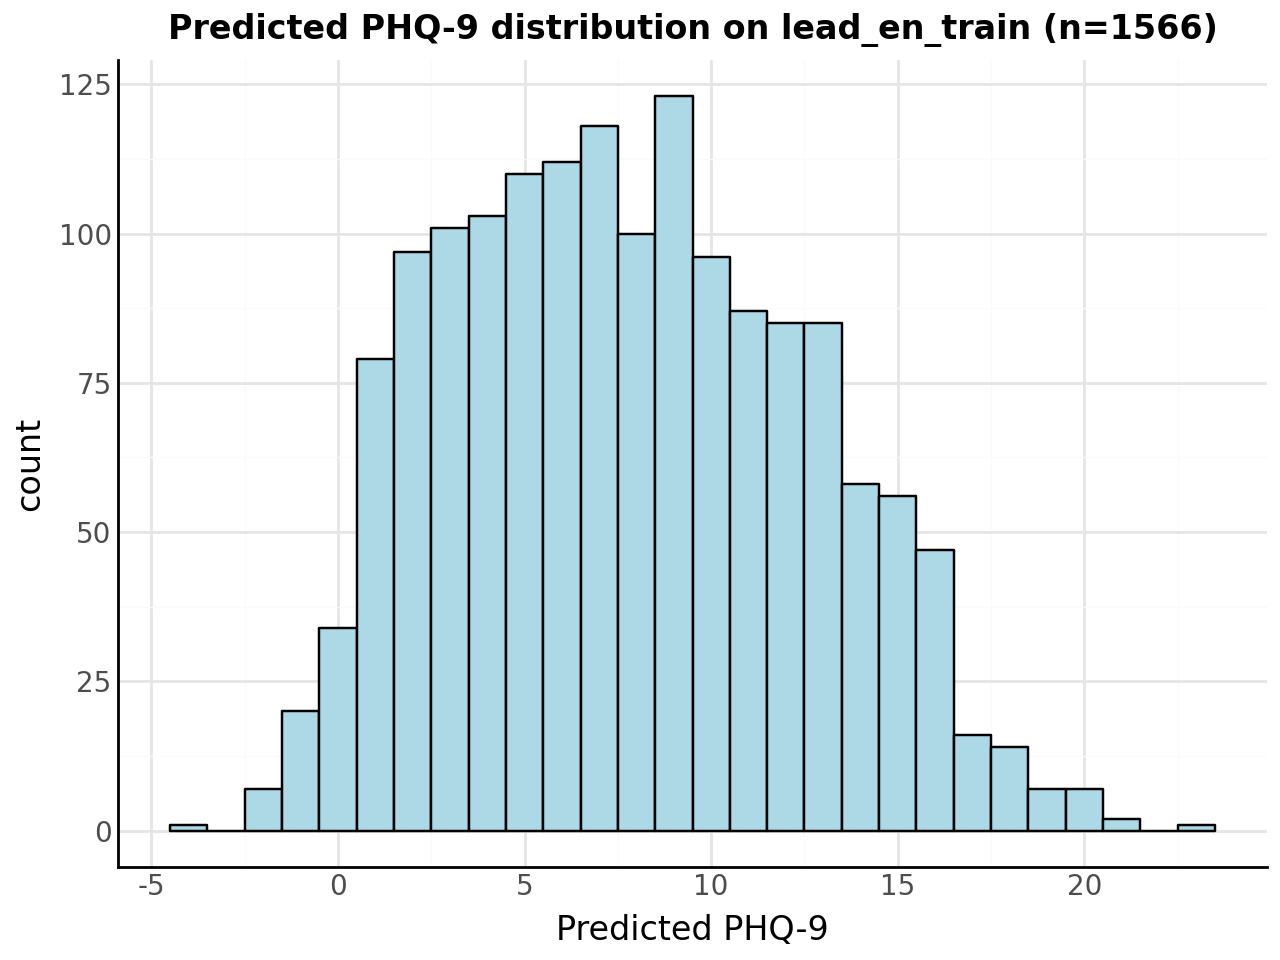

In [4]:
phq9_pred = pd.read_sql(
    "SELECT group_id AS message_id, value AS phq9_pred "
    "FROM `feat$p_ridg_phq9_pred$lead_en_train$message_id` WHERE feat = 'phq9'",
    engine,
)

(
    p9.ggplot(phq9_pred, p9.aes(x="phq9_pred"))
    + p9.geom_histogram(binwidth=1, color="black", fill="lightblue")
    + p9.labs(
        x="Predicted PHQ-9",
        y="count",
        title=f"Predicted PHQ-9 distribution on lead_en_train (n={len(phq9_pred)})",
    )
    + p9.theme_minimal()
    + p9.theme(
        axis_line=p9.element_line(color="black"),
        axis_title=p9.element_text(size=12),
        axis_text=p9.element_text(size=10),
        plot_title=p9.element_text(size=12, face="bold"),
    )
)

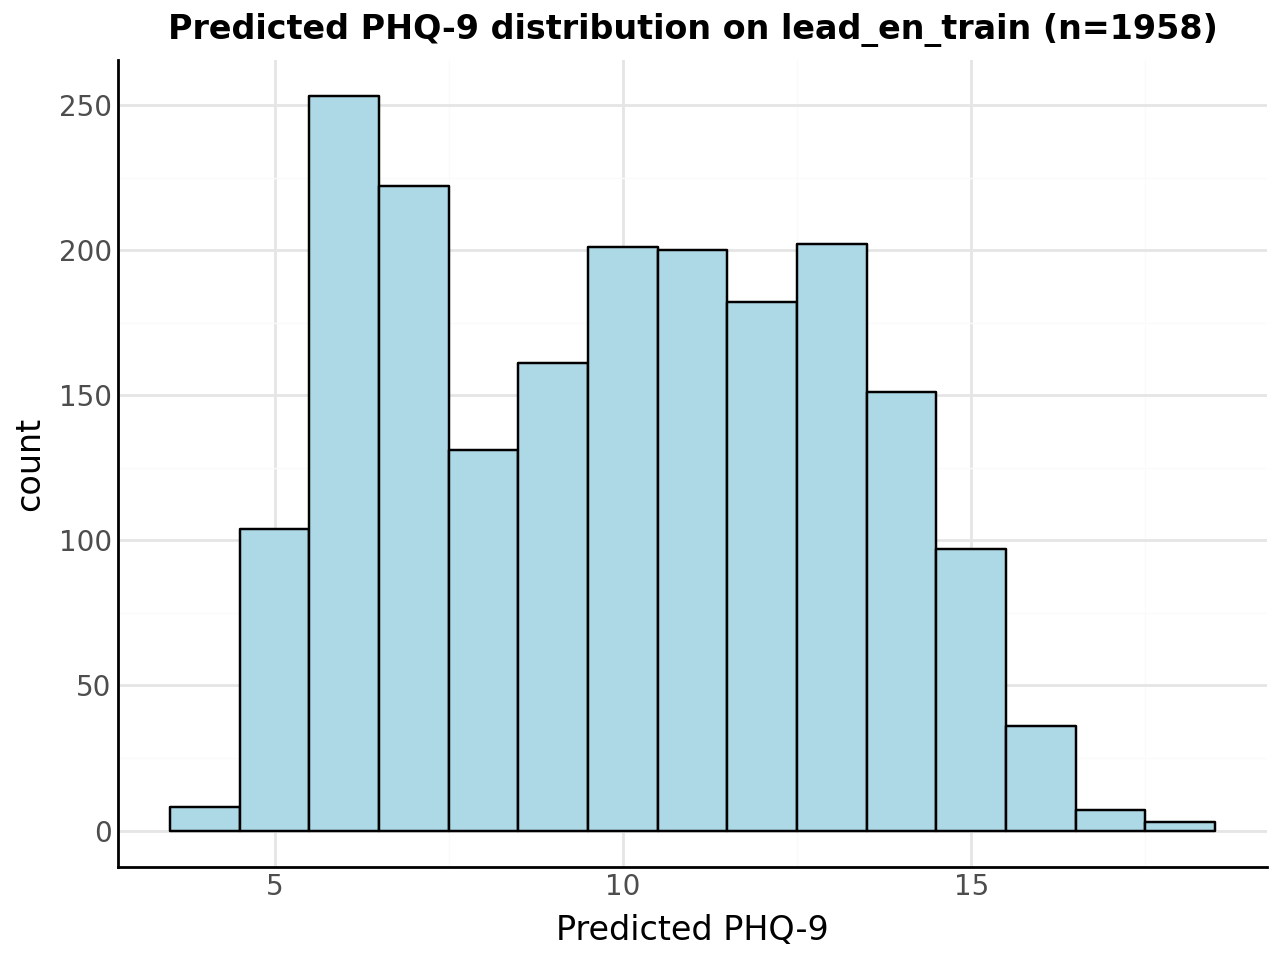

In [5]:
phq9_llm = pd.read_sql(
    "SELECT group_id AS message_id, value AS phq9_pred "
    "FROM `feat$p_ridg_phq9_pred$responses$message_id` WHERE feat = 'phq9'",
    engine
)

(
    p9.ggplot(phq9_llm, p9.aes(x="phq9_pred"))
    + p9.geom_histogram(binwidth=1, color="black", fill="lightblue")
    + p9.labs(
        x="Predicted PHQ-9",
        y="count",
        title=f"Predicted PHQ-9 distribution on lead_en_train (n={len(phq9_llm)})",
    )
    + p9.theme_minimal()
    + p9.theme(
        axis_line=p9.element_line(color="black"),
        axis_title=p9.element_text(size=12),
        axis_text=p9.element_text(size=10),
        plot_title=p9.element_text(size=12, face="bold"),
    )
)

In [ ]:
SCALE_CONFIG = {
    "phq9": {
        "gt_col": "phq9",
        "feat": "phq9",
        "responses_table": "responses_phq9",
        "axis_label": "PHQ-9 score",
        "x_breaks": range(0, 28, 4),
        "x_limits": (0, 27),
    },
    "gad7": {
        "gt_col": "gad7",
        "feat": "gad7",
        "responses_table": "responses_gad7",
        "axis_label": "GAD-7 score",
        "x_breaks": range(0, 22, 3),
        "x_limits": (0, 21),
    },
    "pss10": {
        "gt_col": "pss10",
        "feat": "pss10",
        "responses_table": "responses_pss10",
        "axis_label": "PSS-10 score",
        "x_breaks": range(0, 41, 5),
        "x_limits": (0, 40),
    },
}


def build_scale_plot(scale: str):
    cfg = SCALE_CONFIG[scale]

    gt = pd.read_sql(
        f"SELECT message_id, {cfg['gt_col']} AS score FROM lead_en_valid",
        engine,
    )
    human_lba = pd.read_sql(
        f"SELECT group_id AS message_id, value AS score "
        f"FROM `feat$p_ridg_{cfg['feat']}_pred$lead_en_valid$message_id` "
        f"WHERE feat = '{cfg['feat']}'",
        engine,
    )
    llm_lba = pd.read_sql(
        f"SELECT group_id AS message_id, value AS score "
        f"FROM `feat$p_ridg_{cfg['feat']}_pred${cfg['responses_table']}$message_id` "
        f"WHERE feat = '{cfg['feat']}'",
        engine,
    )

    gt["source"] = "Ground Truth"
    human_lba["source"] = "Human LBA"
    llm_lba["source"] = "LLM LBA"
    long = pd.concat([gt, human_lba, llm_lba], ignore_index=True)

    means = (
        long.groupby("source", as_index=False)["score"]
        .mean()
        .rename(columns={"score": "mean"})
    )

    return (
        p9.ggplot(long, p9.aes(x="score", color="source", fill="source"))
        + p9.geom_density(alpha=0.3)
        + p9.geom_vline(
            means,
            p9.aes(xintercept="mean", color="source", linetype="source"),
            size=0.8,
        )
        + p9.scale_x_continuous(breaks=cfg["x_breaks"], limits=cfg["x_limits"])
        + p9.labs(x=cfg["axis_label"], y="Density")
        + p9.theme_minimal()
        + p9.theme(
            axis_line=p9.element_line(color="black"),
            axis_title=p9.element_text(size=12),
            axis_text=p9.element_text(size=10),
            plot_title=p9.element_text(size=11, face="bold"),
        )
    )

In [ ]:
phq9_plot = build_scale_plot("phq9")
gad7_plot = build_scale_plot("gad7")
pss10_plot = build_scale_plot("pss10")

# plotnine 0.15 composition: `|` (besides), `/` (over). The `+` operator only
# adds layers/themes to a single ggplot. Compose.save() drops width/height
# kwargs — set figure_size via theme() on the composition.
(phq9_plot | gad7_plot | pss10_plot) + p9.theme(figure_size=(20, 5))